In [ ]:
import qiskit.circuit
from qiskit.circuit import (
    QuantumCircuit,
    QuantumRegister,
    AncillaRegister,
    ClassicalRegister,
)
from qiskit.circuit.library import DiagonalGate, QFTGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
from qiskit.quantum_info import Operator, Statevector
from qiskit import transpile
import qiskit.quantum_info as qi
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np

simulator = AerSimulator()

# Eigenvalue preparation
We construct a function `eigenprep(U,d,t,K)` with the following inputs:
- $U$: a $2^n \times 2^n$ diagonal unitary matrix $U$ with $distinct$ eigenvalues $U |x \rangle = e^{2\pi i \varphi(x)}|x \rangle$, where $2^d\varphi(x) \in \mathbb{Z}$ and there exists precisely one eigenvector $|x'\rangle$ with $\varphi(x')=t$.
- $d$: integer such that $2^d\varphi(x) \in \mathbb{Z}$ for all $x$.
- $t$: Desired phase of ouput basis vector.
- $K$: Number of iterations of Grover Search used to find $|x' \rangle$. Defaults to the value maximizing the probability that the search is successful.
  
`eigenprep(U,d,t,K)` outputs a Quantum Circuit that prepares the desired state $|x'\rangle$ satisfying $\varphi(x')=t$ using Grover Search.

The circuit is standard Grover Search, where the Oracle tags the desired state $|x \rangle$ using Quantum Phase Estimation. Therefore we build our circuit in 3 stages:

- Quantum Phase Estimation circuit with $d$ bits of precision.
- Oracle circuit
- Diffuser circuit
- Grover circuit (compose Oracle and Diffuser $K$ times)

## Quantum Phase Estimation Circuit

We begin by constructing a circuit for Quantum Phase estimation. This takes $U$ as above in the form of its diagonal $[U| 0 \rangle, U|2\rangle, \dots U|2^n\rangle]$ and yields a Quantum circuit that transforms a state 

$$|\psi \rangle = \sum_x \alpha_x |x\rangle \otimes |0\rangle$$

into the state

$$\sum_x \alpha_{x} |x\rangle \otimes |\varphi(x) \rangle $$

This uses Controlled $U^{2^i}$ gates for $i=0,\dots,d$, as well as the inverse Quantum Fourier Transform gate.
Note that if we didn't have $t$ such that $2^{d} t \in \mathbb{Z}$, we would have $|\widetilde{\varphi}(x) \rangle$ in place of $|\varphi(x) \rangle$, which would be an estimation of $\varphi(x)$ to $d$ bits of precision. 

In [ ]:
# Returns QPE circuit given n,d, and array U (Unitary= diag(U))
def QPE(unitary, precision: int):
    n = int(np.log2(len(unitary)))
    qr = QuantumRegister(size=n, name="q")  # n qbits Input state
    ar = AncillaRegister(
        size=precision, name="a"
    )  # d qbits for QPE: Ancilla bits which we need to reset to |0> afterwards

    QPE_circ = QuantumCircuit(qr, ar, name="QPE")
    QPE_circ.h(ar)  # Hadamard on ancillas

    unitary_gate = DiagonalGate(unitary)  # Build Unitary gate

    for k in range(precision):
        controlled_unitary_gate = unitary_gate.power(
            1 << k
        ).control()  # Control gate for U^{2^k}
        QPE_circ.append(
            controlled_unitary_gate, [ar[k]] + list(qr)
        )  # Control using kth ancilla, target all quantumregister

    QPE_circ.append(
        QFTGate(precision).inverse(), ar
    )  # Inverse Fourier transform on ancillas
    return QPE_circ

### Example Circuit for Quantum Phase Estimation

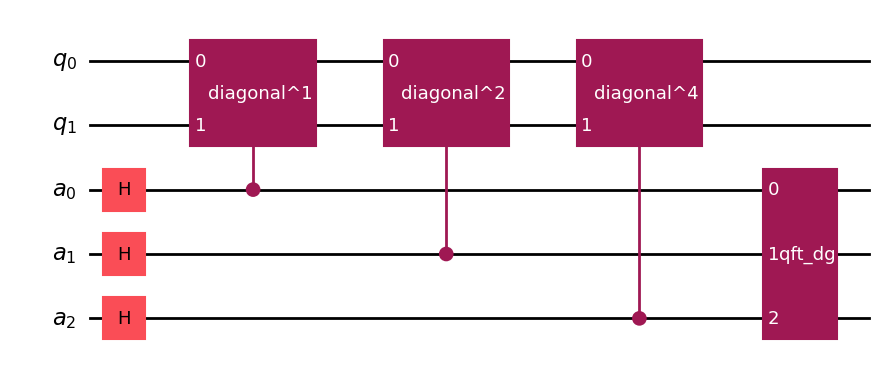

In [ ]:
qc = QPE(np.array([1, 1j, -1, -1j]), 3)
display(qc.draw("mpl"))

Now we construct our oracle ciruit, which should send 

$$ \sum_x \alpha_x |x\rangle \otimes |0\rangle \mapsto  \sum_x (-1)^{f(x)}\alpha_x |x\rangle \otimes |0\rangle,$$

where $f(x)=1$ iff $\varphi(x)=t$, and is $0$ otherwise. We achieve this in 3 steps:
- Apply QPE circuit to send $|x\rangle \otimes |0\rangle$ to $|x\rangle \otimes | \varphi(x) \rangle$.
- Tag state $|x\rangle$ by applying a multi-controlled Z (MCZ) gate, yielding $(-1)^{f(x)} |x\rangle \otimes |\varphi(x) \rangle$, where $f(x)=1$ iff $\varphi(x)=t$, and equals 0 otherwise.
- Apply inverse QPE circuit to yield $|x\rangle \otimes | \varphi(x) \rangle$.
<!-- - As we have to apply this on the ancilla bits, we control using the first $d-1$ ancilla bits, with control state $t_0t_1\dots t_{d-1}$ and use the final ancilla bit as the target. If $t_d = 0$ we must first apply a swap gate to the final ancilla bit before applying the MCZ gate, and then swap again.Finally, and application of the inverse QPE circuit resets the ancilla bits to zero, meaning that our oracle circuit transforms an arbitrary state vector in the desired way. -->

In [ ]:
# Oracle circuit
def oracle(unitary, precision: int, target: float):
    n = int(np.log2(len(unitary)))  # number of qubits needed

    qr = QuantumRegister(size=n, name="a")
    ar = AncillaRegister(size=precision, name="q")
    oracle_circuit = QuantumCircuit(qr, ar, name="oracle")

    QPEGate = QPE(unitary, precision).to_gate()
    oracle_circuit.compose(QPEGate, inplace=True)

    oracle_control_state = int(target * 2**precision) % (
        2 ** (precision - 1)
    )  # first (d-1) bits of target determines our control state

    if target < 0.5:
        oracle_circuit.x(ar[-1])  # force final qbit to be 1

    oracle_circuit.mcp(
        np.pi, ar[0 : precision - 1], ar[-1], ctrl_state=oracle_control_state
    )

    if target < 0.5:
        oracle_circuit.x(ar[-1])  # reset earlier swap if it occured

    oracle_circuit.compose(QPEGate.inverse(), inplace=True)  # uncompute

    return oracle_circuit

### Example Circuit

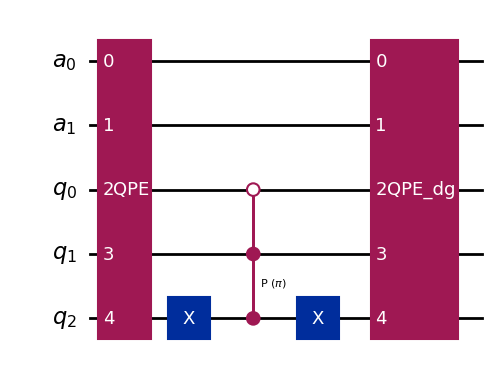

In [ ]:
qc = oracle(np.array([1, 1j, -1, -1j]), 3, 0.25)
display(qc.draw("mpl"))

Now we apply Grover's algorithm. First we construct the diffuser circuit, which applies the operator $\text{diag}(-1,1,\dots,1)$ between Hadamard gates.

In [ ]:
# Diffuser circuit
def diffuser_circuit(qubits: int):
    qr = QuantumRegister(
        size=qubits, name="q"
    )  # Vector to be rotated closer and closer to desired |x>

    diffuser_circuit = QuantumCircuit(
        qr, name="diffuser"
    )  # Does not act on ancilla bits

    diffuser_circuit.h(qr)  # Hadamard all

    # Apply -2 |0><0| + I i.e. reflect |0> around |0> perp
    diffuser_circuit.x(qr[0])  # first bit: 1 <-> 0
    diffuser_circuit.mcp(
        np.pi, qr[1:qubits], qr[0], ctrl_state=0
    )  # Control using _0...0: thus we flip only if we started with |0...0>, else do nothing
    diffuser_circuit.x(qr[0])  # 1 <-> 0
    diffuser_circuit.h(qr)  # Hadamard all

    return diffuser_circuit

Combining the Oracle with the Diffuser yields the Grover Operator, $G$. Now we just have to apply Hadamard gates to our QuantumRegister and then compose with our $G$ circuit $K$ times.

Next, we define our function `eigenprep(U,d,t,K)`:

In [ ]:
def eigenvalue_preparation(unitary, precision: int, target: float, iterations=None):
    if target >= 1:
        raise ValueError("desired phase must be in [0,1)")
    n = int(np.log2(len(unitary)))  # Number of non-ancilla qubits needed

    qr = QuantumRegister(size=n, name="q")
    ar = AncillaRegister(size=precision, name="a")  # qubits for Oracle workspace

    EV_Prep = QuantumCircuit(qr, ar, name="EVP")

    oracle_gate = oracle(unitary, precision, target).to_gate()  # turn oracle into gate
    diffuser_gate = diffuser_circuit(n).to_gate()  # turn diffuser into gate

    EV_Prep.h(qr)  # First must prepare |+> state

    if iterations is None:
        K = int(
            np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(1 << n))) - 1 / 2)
        )  # number of iterations

    for _ in range(K):
        EV_Prep.barrier()
        EV_Prep.compose(oracle_gate, inplace=True)
        EV_Prep.barrier()
        EV_Prep.compose(diffuser_gate, qr, inplace=True)
    return EV_Prep

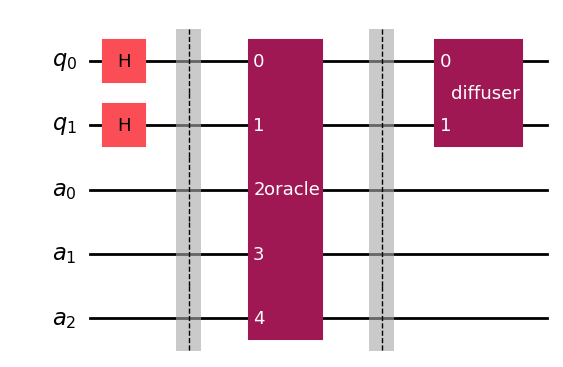

In [ ]:
qc = eigenvalue_preparation(np.array([1, 1j, -1, -1j]), 3, 0.25)
display(qc.draw("mpl"))

Now we run some tests to determine the accuracy of our algorithm. We run eigenvalue_preparation using $d=n$, and $U$ randomly chosen so that $\varphi(x)=t$ for a known $x$ and $t$. Note that the probability of `eigenvalue_preparation` failing is given by $\mathbb{P}(\text{failure})=1-|\langle x | \psi(n) \rangle|^2$, where $\psi(n)$ is the state vector of the circuit outputted by eigenvalue_preparation. We then plot values $(n, \log_2(\mathbb{P}(\text{failure}))$ in an attempt to verify that the $\mathbb{P}(\text{failure}) = O \left( 2^{-n} \right)$, as with Grover search. 

First, we build some functions to help us build a random unitary of specified size with the correct properties to be used in `eigenvalue_preparation`, along with us specifying which state $|x \rangle$ the `eigenvalue_preparation` circuit should yield with high probability:

In [ ]:
# Generates U with theta(desired_state)=target
def random_phase_unitary(
    dimension: int, precision: int, desired_state: int, target: float
):
    # Permututation of [0,...,2**d]\{target}, take first [2**n] to build U from
    v = np.random.permutation(
        np.delete(np.arange(2**precision), int(target * 2**precision))
    )[: (1 << dimension) - 1]
    # Impose theta(desired_state)= target_state
    v = np.insert(v, desired_state, int(target * 2**precision))
    # Exponentiate v to get norm 1
    random_diag = np.exp(np.pi * v / (2 ** (precision - 1)) * 1j)
    return random_diag

In [ ]:
# returns array of probabilities
def eigenprep_probs(unitary, precision: int, target: float):
    psi = Statevector(eigenvalue_preparation(unitary, precision, target))
    probs = np.array(psi.probabilities())[: len(unitary)]
    return probs

In [ ]:
# Generates random unitary and gives probability of success
def success_prob(dimension: int, precision: int, state: int, target: int):
    unitary = random_phase_unitary(dimension, precision, state, target)
    return eigenprep_probs(unitary, precision, target)[state]

<function matplotlib.pyplot.show(close=None, block=None)>

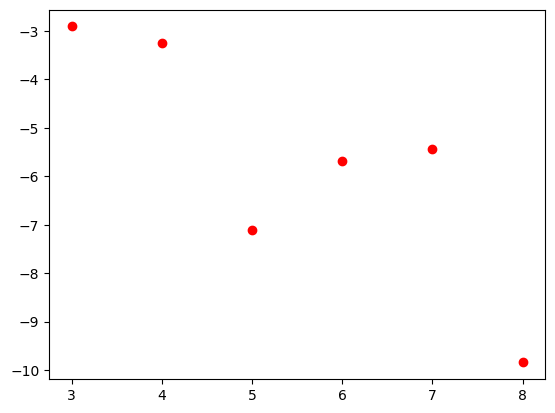

In [ ]:
state = 5
phase = 1 / 4  # state and phase

test_dim = np.arange(3, 9)
success_probs = np.float64(
    [
        success_prob(int(test_dim[i]), int(test_dim[i]), state, phase)
        for i in range(test_dim.size)
    ]
)
failure_probs = 1 - success_probs  # Plot failure probs
# Expect linear if P(failure) = O(2^{-n}): but can only simulate for small n!
failure_probs_log = np.log(failure_probs)
plt.plot(test_dim, failure_probs_log, "ro")
plt.show

Note that $\mathbb{P}(\text{failure})$ is not monotone decreasing for small $n$ due to the floor function involved when calculating the optimal number of iterations of Grover search! However, the impact is negligible once $K = O(\sqrt{2^n})$ becomes sufficiently large. 

We can also generate a single circuit, and then simulate measuring the qubits of our circuit as a different way to estimate the probability of success:

In [ ]:
def eigenvalue_prep_counts(unitary, precision: int, target: float, shots=10000):
    n = int(np.log2(len(unitary)))
    qc = QuantumCircuit(n, n)
    qc = eigenvalue_preparation(unitary, precision, target).compose(qc)
    qc.measure(range(n), range(n))
    qc = transpile(qc, simulator)

    sim_statevector = AerSimulator(method="statevector")
    job_statevector = sim_statevector.run(qc, shots=shots)
    counts_statevector = job_statevector.result().get_counts(0)
    return counts_statevector

Example histogram for $n=7$, $d=8$:

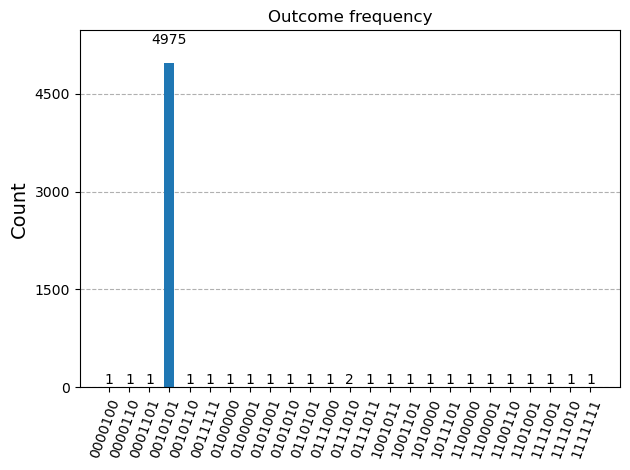

In [ ]:
n = 7
d = 8
desired_state = 21  # binary: 10101
target = 111 / (2**8)  # arbitrary

U = random_phase_unitary(n, d, desired_state, target)
plot_histogram(
    eigenvalue_prep_counts(U, 8, 111 / (2**8), 5000), title="Outcome frequency"
)